#### Unsupervised learning 
- Notes before going through the file

-------------------------

**clustring:**
- k-means
- dbbscan
- heirarchical
- birch algorithm
- dendrogram (**Visualizaton:**)
-------------------------
**reducing diementions:**
- PCA
- t-SNE (**Visualizaton:**)

------------------------
**Anamoly detection:**
- isolation forest
------------------------

 `PCA` & `t-SNE` ,        
  help by reducing the diementions of the data to 2d visualization becomes much easier .

**NOTE:**   
- Since silhouette score is $O(N^2)$ it would take too long. So it will be calculated using a sample of 10,000,

**PS:**

- since The data set multideimentional (21 features), we are suffering from the `curse of diementionality`.

So,
- PCA's resulting princepled components (X_pca95) will be used to fit other models ! 

#### Load-split data:

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, Birch
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from scipy.cluster.hierarchy import dendrogram, linkage

# Makes all random sampling reproducible.
np.random.seed(42)

In [32]:
df = pd.read_csv(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\project1\Data\synthetic_heart_disease_dataset.csv", keep_default_na=False)
print("Original shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().copy()
print("Shape after removing duplicates:", df.shape)

df.head()

Original shape: (50000, 21)
Missing values: 0
Duplicate rows: 0
Shape after removing duplicates: (50000, 21)


,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,None,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,None,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,None,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


In [5]:
heart_data = df.drop(columns= 'Heart_Disease') 

X = pd.get_dummies(heart_data, drop_first= True).copy()  # features , one hot encoding (converts categorical columns in diabetes into numerical columns)
y = df['Heart_Disease'].copy()# target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X.shape)
print("Scaled matrix shape:", X_scaled.shape)
print("Features:", list(X.columns))

Feature matrix shape: (50000, 26)
Scaled matrix shape: (50000, 26)
Features: ['Age', 'Weight', 'Height', 'BMI', 'Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total', 'Gender_Male', 'Smoking_Former', 'Smoking_Never', 'Alcohol_Intake_Low', 'Alcohol_Intake_Moderate', 'Alcohol_Intake_None', 'Physical_Activity_Moderate', 'Physical_Activity_Sedentary', 'Diet_Healthy', 'Diet_Unhealthy', 'Stress_Level_Low', 'Stress_Level_Medium']


### Dimensionality Reduction (PCA):

After one-hot encoding, the data is relatively high-dimensional. **Distance-based clustering becomes more difficult as dimensionality increases** because distances between points become less informative.

PCA is used to create smaller representations of the standardized data:

- a representation retaining approximately **95% of variance** for K-Means;
- a more compact representation retaining approximately **50% of variance** for DBSCAN;
- a **2-component** representation for visualization.

The 2D PCA projection is for visualization only and does not contain all information from the original feature space.

##### Explained variance:

- **To keep %95 variance** 

In [6]:
for i in range(1, len(X.columns)+1 ):
    pca_t = PCA(n_components= i, random_state=42)
    pca_t.fit(X_scaled)
    
    print(f"Number of components: {i}")
    print(f"Each component's explained variance: {pca_t.explained_variance_ratio_}")
    print(f"Sum of explained variance: {pca_t.explained_variance_ratio_.sum()}\n")

Number of components: 1
Each component's explained variance: [0.06454479]
Sum of explained variance: 0.0645447860369478

Number of components: 2
Each component's explained variance: [0.06454479 0.06374024]
Sum of explained variance: 0.12828503021751347

Number of components: 3
Each component's explained variance: [0.06454479 0.06374024 0.06181088]
Sum of explained variance: 0.19009590906110146

Number of components: 4
Each component's explained variance: [0.06454479 0.06374024 0.06181088 0.05945528]
Sum of explained variance: 0.2495511885404405

Number of components: 5
Each component's explained variance: [0.06454479 0.06374024 0.06181088 0.05945528 0.05100984]
Sum of explained variance: 0.30056102382598293

Number of components: 6
Each component's explained variance: [0.06454479 0.06374024 0.06181088 0.05945528 0.05100984 0.05008983]
Sum of explained variance: 0.35065085060408147

Number of components: 7
Each component's explained variance: [0.06454479 0.06374024 0.06181088 0.05945528

To fit the model with %95 variance, `PCA` must keep **22** components.

- **Visualization (Number of componenets vs explained variance):**

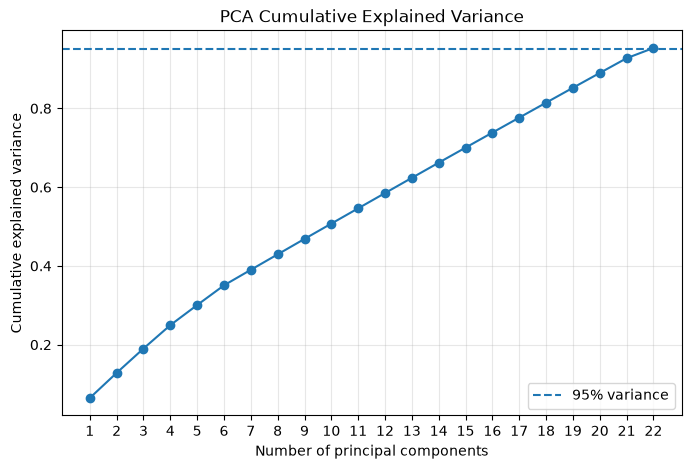

In [8]:
components = np.arange(1, len(cumulative) + 1)

plt.figure(figsize=(8, 5))

plt.plot(components, cumulative, marker="o")

plt.axhline(0.95, linestyle="--", label="95% variance")

plt.xticks(components)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")

plt.title("PCA Cumulative Explained Variance")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### Fitting PCA: 

- **%95 Explained-variance retained PCA Model**

In [23]:
pca95 = PCA(n_components=22, random_state=42)
X_pca95 = pca95.fit_transform(X_scaled) 

print ("Before PCA shape:", X.shape)

print ("After PCA shape:", X_pca95.shape)

explained = pca95.explained_variance_ratio_

cumulative = np.cumsum(explained)

print(f"Cumulative variance retained: {cumulative[-1]:.4f}")


Before PCA shape: (50000, 26)
After PCA shape: (50000, 22)
Cumulative variance retained: 0.9534


- **%50 Explained-variance retained PCA Model**

In [25]:
pca50 = PCA(n_components=10, random_state=42)
X_pca50 = pca50.fit_transform(X_scaled) 

print ("Before PCA shape:", X.shape)

print ("After PCA shape:", X_pca50.shape)

explained = pca50.explained_variance_ratio_

cumulative = np.cumsum(explained)

print(f"Cumulative variance retained: {cumulative[-1]:.4f}")


Before PCA shape: (50000, 26)
After PCA shape: (50000, 10)
Cumulative variance retained: 0.5074


- **2D PCA model**

In [9]:
pca = PCA(n_components=2, random_state=42) # instanciate model
X_pca = pca.fit_transform(X_scaled) 

print ("Before PCA shape: ", X.shape)
print ("After PCA shape: ", X_pca.shape)

print("PCA's Retained variance with 2 components: ",pca.explained_variance_ratio_.sum())

Before PCA shape:  (50000, 26)
After PCA shape:  (50000, 2)
PCA's Retained variance with 2 components:  0.12828503021751347


##### Visualization: PCA projection colored by K-mean clustring:

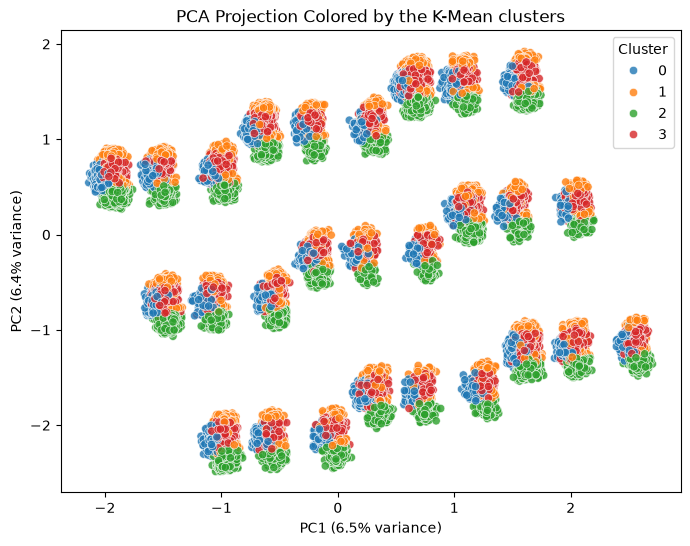

In [14]:
pca_df = pd.DataFrame({
                        "PC1": X_pca[:,0],
                        "PC2": X_pca[:,1],
                        "cluster": km_labels
})

plt.figure(figsize=(8, 6))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="tab10", alpha=0.8)

plt.title("PCA Projection Colored by the K-Mean clusters")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)") # variance ratios for each princeple component
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")

plt.legend(title="Cluster")
plt.show()

### Clustring:
-   Instead of `X_scaled` (containing 26 features),   
PCE's `X_pca95` is used (containing 22 features with 95% of variance retained).

- DBscan will use `X_pca50` (containing 10 features with %50 of variance retained).

#### K-means

##### Finding elbow point:

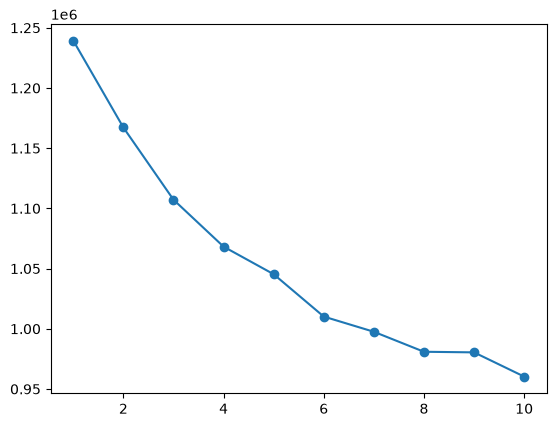

In [11]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca95)
    inertias.append(km.inertia_)
plt.plot(range(1, 11), inertias, marker="o")   # look for the elbow

##### K-means exact optimal n_clusters:

In [39]:
for i in [3,4,5,6]:
    
    km_t = KMeans(n_clusters=i,random_state=42)
    km_t_labels = km_t.fit_predict(X_pca95)

    km_ss = silhouette_score(X_pca95,km_t_labels, sample_size=min(10000, len(X_pca95)), random_state=42)
    print(f"Silhouette score for k-means with {i} clusters, : {km_ss:.4f}")

Silhouette score for k-means with 3 clusters, : 0.0791
Silhouette score for k-means with 4 clusters, : 0.0718
Silhouette score for k-means with 5 clusters, : 0.0604
Silhouette score for k-means with 6 clusters, : 0.0477


##### K-means model:

In [40]:
km = KMeans(n_clusters=4,random_state=42) 
km_labels = km.fit_predict(X_pca95)

km_ss = silhouette_score(X_pca95 , km_labels , sample_size=min(10000, len(X_pca95)) , random_state=42)

print(f"Final K-Means silhouette score: {km_ss:.4f}")
print("Cluster sizes:")
print(pd.Series(km_labels).value_counts().sort_index())

Final K-Means silhouette score: 0.0718
Cluster sizes:
0     9895
1     7869
2    12033
3    20203
Name: count, dtype: int64


##### K-mean cluster interpretaion

A cluster label by itself has no meaning. To understand the result, the generated labels are attached back to the **original, human-readable variables**

The target is still not used to create the clusters.        
Comparing `Heart_Disease` between clusters afterward only tells us whether the natural groups happen to correspond to different disease prevalence.

In [41]:
cluster_profile = df.copy()
cluster_profile["KMeans_Cluster"] = km_labels

numeric_profile_columns = [
    "Age",
    "BMI",
    "Hypertension",
    "Diabetes",
    "Hyperlipidemia",
    "Family_History",
    "Previous_Heart_Attack",
    "Systolic_BP",
    "Diastolic_BP",
    "Heart_Rate",
    "Blood_Sugar_Fasting",
    "Cholesterol_Total",
    "Heart_Disease"
]

numeric_profile_columns = [ col for col in numeric_profile_columns if col in cluster_profile.columns ]

cluster_summary = (cluster_profile.groupby("KMeans_Cluster")[numeric_profile_columns].mean().round(3))

cluster_summary

,Age,BMI,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
KMeans_Cluster,,,,,,,,,,,,,
0,54.459,28.989,0.295,0.201,0.257,0.395,0.100,139.428,89.346,84.395,125.023,224.863,0.466
1,54.728,29.130,0.297,0.196,0.253,0.399,0.099,139.194,89.696,84.485,124.732,224.225,0.461
2,54.302,28.924,0.296,0.200,0.250,0.406,0.100,139.325,89.442,84.412,124.123,224.571,0.463
3,54.460,28.961,0.305,0.200,0.249,0.401,0.099,139.263,89.605,84.485,124.360,224.526,0.464


In [42]:
# distribution of categorical variables inside each cluster.
categorical_profile_columns = [
    "Smoking",
    "Alcohol_Intake",
    "Physical_Activity",
    "Diet",
    "Stress_Level",
    "Gender"
]

for column in categorical_profile_columns:
    if column in cluster_profile.columns:
        print(f"\n--- {column} by K-Means cluster ---")
        display(
            pd.crosstab(
                cluster_profile["KMeans_Cluster"],
                cluster_profile[column],
                normalize="index").round(3)
            )


--- Smoking by K-Means cluster ---


Smoking,Current,Former,Never
KMeans_Cluster,,,
0,0.196,0.199,0.605
1,0.207,0.198,0.595
2,0.200,0.196,0.604
3,0.197,0.198,0.605



--- Alcohol_Intake by K-Means cluster ---


Alcohol_Intake,High,Low,Moderate,None
KMeans_Cluster,,,,
0,0.000,0.000,1.0,0.000
1,0.127,0.366,0.0,0.507
2,0.000,1.000,0.0,0.000
3,0.202,0.000,0.0,0.798



--- Physical_Activity by K-Means cluster ---


...

Diet,Average,Healthy,Unhealthy
KMeans_Cluster,,,
0,0.503,0.297,0.201
1,0.000,0.000,1.000
2,0.627,0.373,0.000
3,0.626,0.374,0.000



--- Stress_Level by K-Means cluster ---


Stress_Level,High,Low,Medium
KMeans_Cluster,,,
0,0.203,0.391,0.406
1,0.204,0.403,0.393
2,0.196,0.398,0.406
3,0.196,0.401,0.403



--- Gender by K-Means cluster ---


Gender,Female,Male
KMeans_Cluster,,
0,0.511,0.489
1,0.491,0.509
2,0.504,0.496
3,0.501,0.499


**Interpretation of the K-Means Groups**

The four K-Means groups show **huge overlap** rather than four sharply separated patient populations.    
 This is also reflected by the relatively low silhouette score. 

 The `Heart_Disease` rate is also very similar between the clusters.    
 Therefore, the K-Means groups should **not** be described as low-, medium-, or high-heart-disease-risk clusters.

#### Dbscan

##### Creating DBscan sample

In [43]:
np.random.seed(42)

sample_indices = np.random.choice(
    X_pca50.shape[0], # X_pca50.shape[0] gives the number of rows.
    size=min(6000, X_pca50.shape[0]),
    replace=False       # replace=False, the same row cannot be selected twice.

)

X_dbscan_sample = X_pca50[sample_indices]

print("Full DBSCAN input shape:", X_pca50.shape)
print("DBSCAN sample shape:", X_dbscan_sample.shape)

Full DBSCAN input shape: (50000, 10)
DBSCAN sample shape: (6000, 10)


##### Finding the optimal Hyperparameters:

In [ ]:
# 1. Define hyperparameter grid

param_grid = {
    'eps': [1.7, 1.8, 1.9, 2.0, 2.1], # or we can use np.linspace(.01, 1.0, 10) or such a thing
    'min_samples': [8, 12, 15, 20]      # or we can use np.arange(2, 20, step=3) or such a thing
}

best_score = -1
best_params = None
best_model = None
best_labels = None

# 2. Iterate through all combinations
for params in ParameterGrid(param_grid):
    
    # it can also be in this shape instead of **params:
    # DBSCAN(eps=params["eps"], min_samples=params["min_samples"])
    dbscan = DBSCAN(**params, metric="euclidean", n_jobs=-1)
    
    labels = dbscan.fit_predict(X_dbscan_sample) # clusters
    
    unique_labels = set(labels) - {-1} # gives the set of unique clusters (ignores the noise (-1))
    noise_ratio = np.mean(labels == -1)
    
    mask = labels != -1 # Ignore noise when calculating silhouette score
    valid_labels = labels[mask]
    
    if len(unique_labels) >= 2 and len(valid_labels) >= 2: # checks if we have at least 2 clusters
        
        score = silhouette_score( X_dbscan_sample[mask], valid_labels, random_state=42)
        
        if noise_ratio <= 0.50 and score > best_score:
            best_score = score
            best_params = params.copy()
            best_model = dbscan
            best_labels = labels.copy()

print(f"Best Parameters: {best_params}")

if best_params is not None:
    print(f"Best Silhouette Score: {best_score:.4f}")
else:
    print("No valid DBSCAN parameter combination was found.")

Best Parameters: {'eps': 1.9, 'min_samples': 20}
Best Silhouette Score: 0.1350


##### Dbscan model:

In [54]:
db = DBSCAN(**best_params)
db_labels = db.fit_predict(X_dbscan_sample)

db_mask = db_labels != -1

db_ss = silhouette_score(X_dbscan_sample[db_mask], db_labels[db_mask], random_state=42)


db_n_clusters = len(set(db_labels[db_mask])) # the clusters
db_noise_ratio = np.mean(db_labels == -1) # noise mean

print("DBSCAN clusters:", db_n_clusters)
print(f"DBSCAN noise ratio: {db_noise_ratio:.2%}")
print(f"DBSCAN silhouette (noise excluded): {db_ss:.4f}")

print("\nCluster/noise counts:")
print(pd.Series(db_labels).value_counts().sort_index())

DBSCAN clusters: 2
DBSCAN noise ratio: 31.92%
DBSCAN silhouette (noise excluded): 0.1350

Cluster/noise counts:
-1    1915
 0    3494
 1     591
Name: count, dtype: int64


**DBSCAN Interpretation**
DBSCAN tests whether the dataset contains groups that are separated by **density** rather than by distance to a centroid.   

**Analysis is judged using:**   

 1- silhouette score     
 2- number of non-noise clusters     
 3- percentage of noise      

For this dataset, dbscan has weak density seperation. as small changes to `eps` seem to merge observations and change results into noise.
      
Therefore, DBSCAN is valuable here as a comparison method. A clustering algorithm is not required to produce a strong result.

#### Heirarchical:

##### Create a Hierarchical-Clustering Sample

In [55]:
np.random.seed(42)

sample_indices = np.random.choice(
    X_pca95.shape[0],
    size=min(2000, X_pca95.shape[0]),
    replace=False
)

X_hier_sample = X_pca95[sample_indices]

print("Full hierarchical input shape:", X_pca95.shape)
print("Hierarchical sample shape:", X_hier_sample.shape)

Full hierarchical input shape: (50000, 22)
Hierarchical sample shape: (2000, 22)


##### Agglomerative Clustering model:

- Ward linkage is between $O(N^2 \log N)$ and $O(N^3)$ , so it will take too long on 50,000 rows and 21 features.
- It shouldn't be used for big data !  (we will be using a sample of our data)

- **Instead BIRCH will we used**

In [ ]:
# hc = AgglomerativeClustering(n_clusters= 4, linkage= 'ward')

# hc_labels = hc.fit_predict(X_scaled)

# hc_ss = silhouette_score(X_scaled , hc_labels, sample_size=10000, random_state=42)
# print (f"Silhouette score for heirachical clustering: {hc_ss:.4f}")

##### BIRCH
**BIRCH**: Balanced Iterative Reducing and Clustering using Hierarchies.

- It builds a tree structure in a single pass over the data.

In [ ]:

# n_clusters=4 tells BIRCH to group the sub-clusters into 4 main clusters at the end.
# threshold determines the maximum radius of a sub-cluster.
birch_model = Birch(n_clusters=4, threshold=1.5)

# 2. Fit the model and get labels
birch_labels = birch_model.fit_predict(X_scaled)

# 3. Calculate Silhouette Score (SEE IMPORTANT NOTE BELOW)
birch_ss = silhouette_score(X_scaled, birch_labels, sample_size=10000, random_state=42)

print(f"Silhouette score for BIRCH clustering: {birch_ss:.4f}")

##### Dendrogram:

In [ ]:
plt.Figure(figsize= (12,12))

Z = linkage(X_scaled, method = 'ward')
dendrogram( Z, truncate_mode="level", p=6 )

plt.title("Hierarchical Clustering Dendrogram (Sample)")
plt.xlabel("Cluster / Sample Group")
plt.ylabel("Ward Distance")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Dimensionality Reduction (t-SNE):

##### Fitting t-SNE: (2D)

In [18]:
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne= tsne.fit_transform(X_scaled)

##### Visualization: t-SNE projection colored by K-mean clustring:

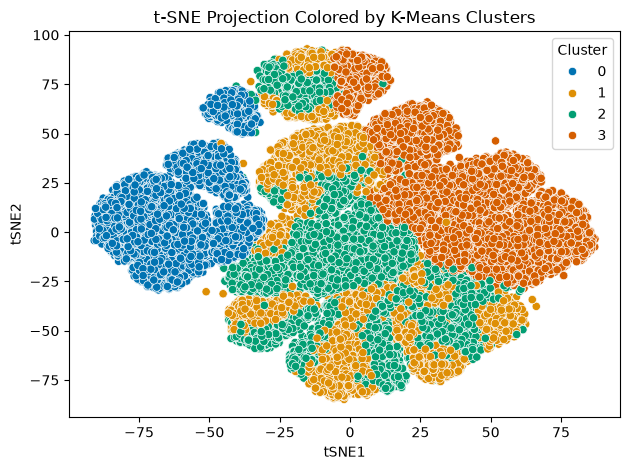

In [24]:
tsne_df = pd.DataFrame({"tSNE1": X_tsne[:, 0],
                         "tSNE2": X_tsne[:, 1],
                         "cluster": km_labels })


sns.scatterplot(data=tsne_df, x="tSNE1", y="tSNE2", hue="cluster", palette="colorblind" )

plt.title("t-SNE Projection Colored by K-Means Clusters")

plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

##### Isolation forest

In [20]:
iso = IsolationForest(contamination=0.05, random_state=42)

anomaly_label = iso.fit_predict(X_scaled)
anomaly_score = iso.decision_function(X_scaled) # used for calculating the most anamolous* points

results= df.copy()

results["anomaly"] = anomaly_label
results["anomaly_score"] = anomaly_score

n_anomalies = (results["anomaly"] == -1).sum()

print(f"Number of anomalies flagged: {n_anomalies} out of {len(results)} points\n")
print(results["anomaly"].value_counts())

Number of anomalies flagged: 2500 out of 50000 points

anomaly
 1    47500
-1     2500
Name: count, dtype: int64


##### Most 5 anomalous points :

In [21]:
most_anomalous = results[results["anomaly"] == -1].nsmallest(5, "anomaly_score")

most_anomalous

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease,anomaly,anomaly_score
46183,71,Female,99,186,36.4,Former,Moderate,Sedentary,Unhealthy,High,...,1,1,146,117,97,91,215,1,-1,-0.056702
14130,78,Male,84,181,21.8,Current,Low,Sedentary,Unhealthy,Low,...,1,1,118,107,74,167,165,1,-1,-0.055479
18380,74,Male,94,197,26.5,Former,Moderate,Sedentary,Healthy,Medium,...,0,1,159,110,61,106,223,1,-1,-0.054431
10427,50,Male,108,198,39.0,Former,Moderate,Sedentary,Unhealthy,Medium,...,1,1,129,69,89,110,201,1,-1,-0.053998
12511,74,Male,84,179,34.2,Former,Moderate,Sedentary,Unhealthy,Medium,...,0,1,106,62,61,172,191,1,-1,-0.052106


##### Isolation forest anomalies visual:

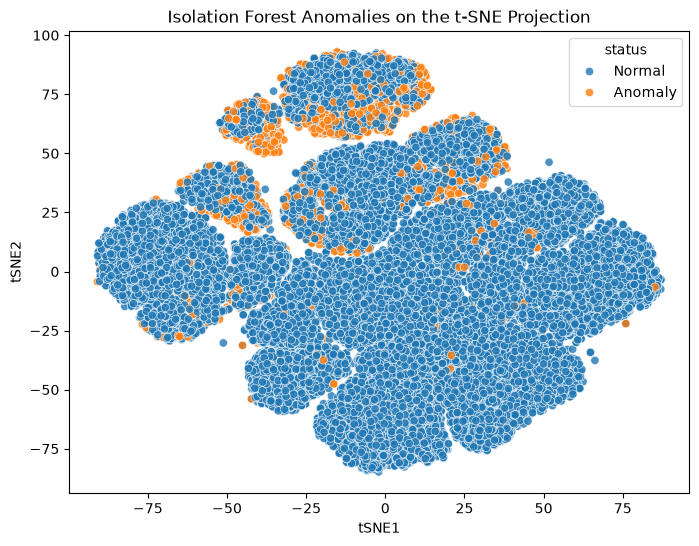

In [22]:

anomaly_plot = pd.DataFrame({
                             "tSNE1": X_tsne[:, 0],
                             "tSNE2": X_tsne[:, 1],
                             "status": np.where(anomaly_label == -1, "Anomaly", "Normal")
})

plt.figure(figsize=(8, 6))

sns.scatterplot(data=anomaly_plot, x="tSNE1", y="tSNE2", hue="status", alpha=0.8)

plt.title("Isolation Forest Anomalies on the t-SNE Projection")
plt.show()